# Task 1.1 Baseline: Base Model on GSM8K

In [4]:
import re
import torch
from tqdm import tqdm
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

# System prompt: match GSM8K training format (step-by-step with <<...>>, end with #### <number>).

SYSTEM_PROMPT = """
You are a math tutor. 
Solve the problem inside <reasoning> tags, then provide the final integer after "####".

EXAMPLE:

Problem: 12 + 7

Response:

<reasoning>
1. Start with 12.
2. Add 7.
3. 12 + 7 = 19.
<reasoning>
#### 19

It is CRUCIAL that you follow the format EXACTLY. The answer must be provided in the format "#### <integer>" ONLY. 
Please double-check that the format of the answer is "#### <integer>" ONLY. 
"""


In [5]:
# ── Answer extraction ──
# Primary: #### <number> (GSM8K format). Fallback: Answer: <number>, then \boxed{...}.

def extract_boxed(text):
    """Extract content from the last \\boxed{...}, handling nested braces."""
    if not text or "\\boxed{" not in text:
        return None
    start = text.rfind("\\boxed{")
    if start == -1:
        return None
    start += len("\\boxed{")
    depth = 1
    i = start
    while i < len(text) and depth > 0:
        if text[i] == "{":
            depth += 1
        elif text[i] == "}":
            depth -= 1
        i += 1
    if depth == 0:
        return text[start : i - 1].strip()
    return None


def extract_ground_truth(raw_answer):
    """Extract ground-truth answer from GSM8K answer field (ends with #### <number>)."""
    m = re.search(r"####\s*(.+)", raw_answer)
    if m:
        return normalize_answer(m.group(1).strip())
    return normalize_answer(raw_answer.strip())


def normalize_answer(s):
    """Strip and remove commas for numeric comparison."""
    return s.strip().replace(",", "").strip()


def answers_match(pred, gt):
    """Compare predicted and ground-truth answers (both normalized). GSM8K answers are integers."""
    if pred is None or gt is None:
        return False
    pred, gt = normalize_answer(pred), normalize_answer(gt)
    try:
        return int(float(pred)) == int(float(gt))
    except ValueError:
        return pred == gt


def extract_model_answer(text):
    """Extract final answer: prefer #### <number> (GSM8K format), then 'Answer: <number>', then \\boxed{...}."""
    if not text:
        return None
    m = re.search(r"####\s*(.+?)(?:\n|$)", text)
    if m:
        return normalize_answer(m.group(1).strip())
    matches = list(re.finditer(r"Answer:\s*([^\s\n]+)", text, re.IGNORECASE))
    if matches:
        return normalize_answer(matches[-1].group(1))
    boxed = extract_boxed(text)
    if boxed is not None:
        return normalize_answer(boxed)
    return None

**Why does the model sometimes use `\boxed{}` instead of "Answer:"?**  
The base model (Qwen2.5-1.5B-Instruct) was trained on a lot of math and reasoning data where final answers are often written as `\boxed{...}` (e.g. from competition math and papers). That format is a strong prior, so the model may use it even when the system prompt asks for "Answer: &lt;number&gt;". We still prefer "Answer:" in the prompt for consistency, but the extractor falls back to `\boxed{...}` so we don't count correct answers as wrong when the model uses that format.

In [6]:
# Load GSM8K test set and take first 100 questions (fixed subset for all experiments)
gsm8k = load_dataset("openai/gsm8k", "main", split="test")
num_test = 100
test_questions = [gsm8k[i]["question"] for i in range(num_test)]
test_ground_truth = [extract_ground_truth(gsm8k[i]["answer"]) for i in range(num_test)]
print(f"Loaded {num_test} test questions. Example GT: {test_ground_truth[0]!r}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

Loaded 100 test questions. Example GT: '18'


In [11]:
# ── Model loading and batched generation ──

def load_model(model_name=MODEL_NAME):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    tokenizer.padding_side = "left"
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        attn_implementation="eager",
    )
    model.eval()
    print(f"Loaded: {model_name}")
    return model, tokenizer


def build_prompts(tokenizer, questions):
    """Build chat-formatted prompt strings for a list of questions."""
    prompts = []
    for q in questions:
        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": q},
        ]
        prompts.append(
            tokenizer.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True
            )
        )
    return prompts


def generate_batch(model, tokenizer, questions, max_new_tokens=2048):
    """Generate responses for a batch of questions."""
    prompts = build_prompts(tokenizer, questions)
    inputs = tokenizer(
        prompts, return_tensors="pt", padding=True, truncation=True, max_length=2048
    ).to(model.device)
    prompt_len = inputs["input_ids"].shape[1]
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    responses = []
    for i in range(len(questions)):
        new_tokens = out[i][prompt_len:]
        responses.append(tokenizer.decode(new_tokens, skip_special_tokens=True))
    return responses

In [9]:
def evaluate_gsm8k(model, tokenizer, questions, ground_truths, batch_size=16):
    """Zero-shot eval on GSM8K. Returns accuracy and list of (pred, gt, correct, raw_response)."""
    correct = 0
    records = []
    num_samples = len(questions)
    for start in tqdm(range(0, num_samples, batch_size), desc="Evaluating"):
        end = min(start + batch_size, num_samples)
        batch_q = questions[start:end]
        batch_gt = ground_truths[start:end]
        responses = generate_batch(model, tokenizer, batch_q)
        for i, (resp, gt) in enumerate(zip(responses, batch_gt)):
            pred = extract_model_answer(resp)
            is_correct = answers_match(pred, gt)
            if is_correct:
                correct += 1
            records.append({"pred": pred, "gt": gt, "correct": is_correct, "response": resp})
    accuracy = correct / num_samples
    return accuracy, records

In [106]:
# Run baseline evaluation (QUESTION 1)
model, tokenizer = load_model()
accuracy, records = evaluate_gsm8k(
    model, tokenizer, test_questions, test_ground_truth, batch_size=16
)
print(f"\nBase model accuracy on 100 GSM8K test questions: {accuracy:.2%}")
print(f"Correct: {sum(r['correct'] for r in records)} / {len(records)}")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loaded: Qwen/Qwen2.5-1.5B-Instruct


Evaluating: 100%|██████████| 7/7 [00:57<00:00,  8.19s/it]


Base model accuracy on 100 GSM8K test questions: 36.00%
Correct: 36 / 100


## QUESTION 2: Inspect 3 Incorrect Cases

In [109]:
# Get indices of incorrect predictions (run after Q1 evaluation)
incorrect_indices = [i for i, r in enumerate(records) if not r["correct"]]
print(f"Total incorrect: {len(incorrect_indices)}. Inspecting first 3.\n")

# Show 3 failure cases
num_inspect = min(3, len(incorrect_indices))
for case_num, idx in enumerate(incorrect_indices[:num_inspect], 1):
    q = test_questions[idx]
    r = records[idx]
    print("=" * 80)
    print(f"FAILURE CASE {case_num}")
    print("=" * 80)
    print("\nQuestion:")
    print(q)
    print("\nModel's solution (excerpt):")
    # Show first ~600 chars; full response available as r["response"] if needed
    excerpt = r["response"]
    print(excerpt)
    print("\nExtracted answer:", repr(r["pred"]))
    print("Ground-truth answer:", repr(r["gt"]))
    print()

Total incorrect: 64. Inspecting first 3.

FAILURE CASE 1

Question:
Josh decides to try flipping a house.  He buys a house for $80,000 and then puts in $50,000 in repairs.  This increased the value of the house by 150%.  How much profit did he make?

Model's solution (excerpt):
<reasoning>
1. First, calculate the total cost of buying the house including repairs:
   - Cost of the house: $80,000
   - Amount spent on repairs: $50,000
   - Total cost: $80,000 + $50,000 = $130,000

2. Next, determine the increase in the value of the house due to the renovations:
   - Increase in value: 150% of the original price
   - Value increase amount: 150/100 * $80,000 = $120,000

3. Calculate the new value of the house after the renovations:
   - New value: Original price + Value increase
   - New value: $80,000 + $120,000 = $200,000

4. Finally, find the profit made by subtracting the total cost from the new value:
   - Profit: New value - Total cost
   - Profit: $200,000 - $130,000 = $170,000
</reas

### Failure mode classification and patterns

**Case 1 – Failure mode:** Arithmetic slip  

**Case 2 – Failure mode:** formatting/extraction issue 

**Case 3 – Failure mode:** Misunderstanding the problem (and reasoning error)  

**Recurring patterns:** I don't see any recurring issues in the 3 mistakes above. Since the model is small, it isn't surprising that it makes a variety of mistakes 

## QUESTION 3: LoRA Hyperparameters 

### 1. LoRA rank (r)

**What it controls:** LoRA adapts a weight matrix $W$ by a low-rank update $W' = W + B A$, where $B$ is $(d \times r)$ and $A$ is $(r \times k)$. The rank $r$ directly controls the capacity of the adapter: how many independent "directions" the model can use to adapt each layer.

**If you increase $r$:**  
- **Pros:** More capacity to learn task-specific patterns; can improve accuracy and fit harder tasks.  
- **Cons:** higher memory compute per step; longer training; higher overfitting risk.

**If you decrease $r$:**  
- **Pros:** lower memory and compute; faster steps; less overfitting. 
- **Cons:** may underfit on complex tasks; model might not be able to capture all needed adaptations.

---

### 2. LoRA alpha

**What it controls:** The LoRA forward pass is typically $y = Wx + (\alpha/r)\, (BA)x$. So the adapter's output is scaled by $\alpha/r$. For a fixed $r$, $\alpha$ controls the influence of the adapter relative to the frozen base model. 

**If you increase $\alpha$:**  
- **Pros:** Stronger effective learning signal from the adapter; can speed up adaptation and make the fine-tuned behavior more pronounced.  
- **Cons:** Can make training less stable (larger effective step size); in extreme cases the adapter can dominate and hurt generalization.

**If you decrease $\alpha$:**  
- **Pros:** **More stable** training; adapter changes are gentler.  
- **Cons:** **slower** adaptation; may need more epochs or risk underfitting if the model barely changes.

---

### 3. Gradient accumulation

**What it controls:** Number of mini-batch forward/backward passes before each optimizer step;

**If you increase gradient accumulation:**  
- **Pros:** Larger effective batch size; more stable gradient estimates; often smoother loss and more predictable training;
- **Cons:** more time and compute; can generalize slightly worse.

**If you decrease gradient accumulation:**  
- **Pros:** Fewer passes per step; smaller effective batch.  
- **Cons:** less stable training, may need lower learning rate or more careful tuning

## QUESTION 4: Parameter counts

In [2]:
# Q4: Base model and LoRA parameter counts (default: r=8, alpha=16, attention only q,k,v,o)
import torch
from transformers import AutoModelForCausalLM
from peft import LoraConfig, get_peft_model

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="eager",
)
total_params = sum(p.numel() for p in model.parameters())

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_config)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
pct = 100.0 * trainable_params / total_params

print("(a) Total parameters (base model):", f"{total_params:,}")
print("(b) Trainable LoRA parameters:", f"{trainable_params:,}")
print("(c) Percentage of parameters trained:", f"{pct:.2f}%")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

(a) Total parameters (base model): 1,543,714,304
(b) Trainable LoRA parameters: 2,179,072
(c) Percentage of parameters trained: 0.14%


**Why the percentage is small:** We only train the LoRA adapter matrices, not the full weight matrices. The base model (1.5B params) is frozen.

**How LoRA achieves this:** For each targeted linear layer $W$, LoRA adds a low-rank update $W' = W + B A$ with $B$ (d X r) and $A$ (r X d). So instead of training $d^2$ parameters per layer, we train $2rd$ (with $r=8$). Only the attention projections are adapted, and with small $r$ the total trainable parameters are on the order of a few million instead of billions- hence a small fraction of the full model.

## QUESTION 5: LoRA SFT using 1,000 Training Examples

In [8]:
# Q5: Load 1,000 train examples, build SFT dataset, train LoRA with default hyperparameters (no trl)
import torch
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
MAX_SEQ_LENGTH = 1024

# Load 1,000 training examples
gsm8k_train = load_dataset("openai/gsm8k", "main", split="train").select(range(1000))

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"  # for training

def tokenize_sft(ex):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": ex["question"]},
        {"role": "assistant", "content": ex["answer"]},
    ]
    prompt_messages = messages[:2]  # system + user
    prompt_text = tokenizer.apply_chat_template(
        prompt_messages, tokenize=False, add_generation_prompt=True
    )
    full_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False
    )
    prompt_ids = tokenizer(prompt_text, add_special_tokens=False).input_ids
    full_ids = tokenizer(full_text, add_special_tokens=False, truncation=True, max_length=MAX_SEQ_LENGTH).input_ids
    prompt_len = len(prompt_ids)
    if prompt_len >= len(full_ids):
        labels = full_ids  # no prompt masking fallback
    else:
        labels = [-100] * prompt_len + full_ids[prompt_len:]
    return {"input_ids": full_ids, "labels": labels, "attention_mask": [1] * len(full_ids)}

train_dataset = gsm8k_train.map(
    tokenize_sft,
    remove_columns=gsm8k_train.column_names,
    desc="Tokenizing",
)

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="eager",
)
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, lora_config)

training_args = TrainingArguments(
    output_dir="./q5_lora_gsm8k",
    per_device_train_batch_size=8,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    num_train_epochs=1,
    bf16=True,
    logging_steps=20,
    save_strategy="epoch",
)

def collate_fn(batch):
    pad_id = tokenizer.pad_token_id
    max_len = max(len(b["input_ids"]) for b in batch)
    max_len = min(max_len, MAX_SEQ_LENGTH)
    input_ids = []
    labels = []
    attention_mask = []
    for b in batch:
        ids = b["input_ids"][:max_len]
        lbls = b["labels"][:max_len]
        pad_len = max_len - len(ids)
        input_ids.append(ids + [pad_id] * pad_len)
        labels.append(lbls + [-100] * pad_len)
        attention_mask.append([1] * len(ids) + [0] * pad_len)
    return {
        "input_ids": torch.tensor(input_ids, dtype=torch.long),
        "labels": torch.tensor(labels, dtype=torch.long),
        "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
    }

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=collate_fn,
)
trainer.train()
trainer.save_model("./q5_lora_gsm8k")
tokenizer.save_pretrained("./q5_lora_gsm8k")
print("LoRA SFT training done. Adapter saved to ./q5_lora_gsm8k")

Tokenizing:   0%|          | 0/1000 [00:00<?, ? examples/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss
20,0.450724


LoRA SFT training done. Adapter saved to ./q5_lora_gsm8k


In [108]:
# Q5: Evaluate trained LoRA on the same 100 GSM8K test questions as Q1
# (Run the data-load and evaluate_gsm8k cells above first, or run the notebook from the start.)
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
adapter_path = "./q5_lora_gsm8k"

tokenizer = AutoTokenizer.from_pretrained(adapter_path)
tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="eager",
)
model = PeftModel.from_pretrained(model, adapter_path)
model.eval()

accuracy, records_q5 = evaluate_gsm8k(
    model, tokenizer, test_questions, test_ground_truth, batch_size=16
)
print(f"\nQ5 LoRA SFT accuracy on 100 GSM8K test questions: {accuracy:.2%}")
print(f"Correct: {sum(r['correct'] for r in records_q5)} / {len(records_q5)}")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 7/7 [01:04<00:00,  9.18s/it]


Q5 LoRA SFT accuracy on 100 GSM8K test questions: 46.00%
Correct: 46 / 100


**Comment on whether the improvement over the baseline matches expectations**

The LoRA SFT model gets a +10 percent increase. This improvement is in line with expectations: with only 1 epoch and 1,000 training examples, we are doing light supervised fine-tuning on a small slice of GSM8K. 

## QUESTION 6 – Hypothesis

Yes, I think scaling to 3000 examples is meaningful and will help the model learn better. I predict a gain of 3 to 6 percent. My reasoning is that additional example contributes less once the core patterns are learned. 

## QUESTION 7 – Scaling LoRA SFT to 3,000 examples

In [13]:
# Q7 (standalone): Train LoRA SFT on 3,000 GSM8K examples
import re
import torch
from tqdm import tqdm
from datasets import load_dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    Trainer,
    TrainingArguments,
)
from peft import LoraConfig, get_peft_model

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
MAX_SEQ_LENGTH = 1024

# Load 3,000 training examples
gsm8k_train_3k = load_dataset("openai/gsm8k", "main", split="train").select(range(3000))

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"  # for training


def tokenize_sft_q7(ex):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": ex["question"]},
        {"role": "assistant", "content": ex["answer"]},
    ]
    prompt_messages = messages[:2]  # system + user
    prompt_text = tokenizer.apply_chat_template(
        prompt_messages, tokenize=False, add_generation_prompt=True
    )
    full_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=False
    )
    prompt_ids = tokenizer(prompt_text, add_special_tokens=False).input_ids
    full_ids = tokenizer(
        full_text,
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
    ).input_ids
    prompt_len = len(prompt_ids)
    if prompt_len >= len(full_ids):
        labels = full_ids
    else:
        labels = [-100] * prompt_len + full_ids[prompt_len:]
    return {
        "input_ids": full_ids,
        "labels": labels,
        "attention_mask": [1] * len(full_ids),
    }

train_dataset_3k = gsm8k_train_3k.map(
    tokenize_sft_q7,
    remove_columns=gsm8k_train_3k.column_names,
    desc="Tokenizing Q7 (3k examples)",
)

model_q7 = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="eager",
)
lora_config_q7 = LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    bias="none",
    task_type="CAUSAL_LM",
)
model_q7 = get_peft_model(model_q7, lora_config_q7)

training_args_q7 = TrainingArguments(
    output_dir="./q7_lora_gsm8k_3k",
    per_device_train_batch_size=8,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.05,
    num_train_epochs=1,
    bf16=True,
    logging_steps=20,
    save_strategy="epoch",
)


def collate_fn_q7(batch):
    pad_id = tokenizer.pad_token_id
    max_len = max(len(b["input_ids"]) for b in batch)
    max_len = min(max_len, MAX_SEQ_LENGTH)
    input_ids = []
    labels = []
    attention_mask = []
    for b in batch:
        ids = b["input_ids"][:max_len]
        lbls = b["labels"][:max_len]
        pad_len = max_len - len(ids)
        input_ids.append(ids + [pad_id] * pad_len)
        labels.append(lbls + [-100] * pad_len)
        attention_mask.append([1] * len(ids) + [0] * pad_len)
    return {
        "input_ids": torch.tensor(input_ids, dtype=torch.long),
        "labels": torch.tensor(labels, dtype=torch.long),
        "attention_mask": torch.tensor(attention_mask, dtype=torch.long),
    }

trainer_q7 = Trainer(
    model=model_q7,
    args=training_args_q7,
    train_dataset=train_dataset_3k,
    data_collator=collate_fn_q7,
)

trainer_q7.train()
trainer_q7.save_model("./q7_lora_gsm8k_3k")
tokenizer.save_pretrained("./q7_lora_gsm8k_3k")
print("LoRA SFT (3k examples) done. Adapter saved to ./q7_lora_gsm8k_3k")

Tokenizing Q7 (3k examples):   0%|          | 0/3000 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Step,Training Loss
20,0.473073
40,0.372872
60,0.366062
80,0.368722


LoRA SFT (3k examples) done. Adapter saved to ./q7_lora_gsm8k_3k


In [13]:
# Q7: Evaluate the 3k-example LoRA model on the same 100 GSM8K test questions
# Assumes test_questions, test_ground_truth, and evaluate_gsm8k are already defined (from Q1 setup).
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
adapter_path_q7 = "./q7_lora_gsm8k_3k"

tokenizer_q7 = AutoTokenizer.from_pretrained(adapter_path_q7)
tokenizer_q7.padding_side = "left"
if tokenizer_q7.pad_token is None:
    tokenizer_q7.pad_token = tokenizer_q7.eos_token

model_q7 = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="eager",
)
model_q7 = PeftModel.from_pretrained(model_q7, adapter_path_q7)
model_q7.eval()

accuracy_q7, records_q7 = evaluate_gsm8k(
    model_q7, tokenizer_q7, test_questions, test_ground_truth, batch_size=16
)
print(f"\nQ7 LoRA (3k examples) accuracy on 100 GSM8K test questions: {accuracy_q7:.2%}")
print(f"Correct: {sum(r['correct'] for r in records_q7)} / {len(records_q7)}")

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Evaluating: 100%|██████████| 7/7 [00:55<00:00,  7.96s/it]


Q7 LoRA (3k examples) accuracy on 100 GSM8K test questions: 46.00%
Correct: 46 / 100


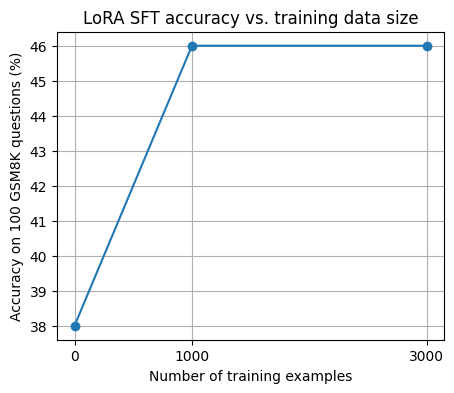

In [ ]:
# Q7: Plot accuracy vs. number of training examples

import matplotlib.pyplot as plt

# Fill in with your measured accuracies if they differ
acc_0 = 0.38      # baseline (no SFT, Q1)
acc_1000 = 0.46   # LoRA SFT with 1,000 examples (Q5)
acc_3000 = float(accuracy_q7)  # LoRA SFT with 3,000 examples (Q7)

xs = [0, 1000, 3000]
ys = [acc_0, acc_1000, acc_3000]

plt.figure(figsize=(5, 4))
plt.plot(xs, [y * 100 for y in ys], marker="o")
plt.xlabel("Number of training examples")
plt.ylabel("Accuracy on 100 GSM8K questions (%)")
plt.title("LoRA SFT accuracy vs. training data size")
plt.grid(True)
plt.xticks(xs)
plt.show()

**Trend and diminishing returns:** Accuracy increases from the baseline of examples (36%) to 1,000-example LoRA (46%). But, it stays the same when increased to 3,000 examples (46%). This is the typical diminishing-returns pattern in SFT: the first examples that the model is trained on correct the model’s biggest mistakes and give large gains, while additional data mostly refines behavior and yields smaller incremental improvements. Beyond a certain point, the model's accuracy can also stop increasing (as in our case). 

## Question 8: Baseline vs Fine Tuning

In [10]:
# Q8: Re-run three earlier failure cases on the Q5 LoRA model
# Assumes:
# - Q1 setup cells (SYSTEM_PROMPT, extract_model_answer, generate_batch, etc.) are already run
# - The Q5 LoRA adapter is saved at ./q5_lora_gsm8k

from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel

MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
adapter_path_q5 = "q5_lora_gsm8k"

# Load tokenizer and LoRA-adapted model for Q5
tokenizer_q5 = AutoTokenizer.from_pretrained(adapter_path_q5)
if tokenizer_q5.pad_token is None:
    tokenizer_q5.pad_token = tokenizer_q5.eos_token
# For generation we want left padding
tokenizer_q5.padding_side = "left"

model_q5 = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    attn_implementation="eager",
)
model_q5 = PeftModel.from_pretrained(model_q5, adapter_path_q5)
model_q5.eval()

# The three failure-case questions (same wording as before)
q8_questions = [
    "Josh decides to try flipping a house.  He buys a house for $80,000 and then puts in $50,000 in repairs.  This increased the value of the house by 150%.  How much profit did he make?",
    "Every day, Wendi feeds each of her chickens three cups of mixed chicken feed, containing seeds, mealworms and vegetables to help keep them healthy.  She gives the chickens their feed in three separate meals. In the morning, she gives her flock of chickens 15 cups of feed.  In the afternoon, she gives her chickens another 25 cups of feed.  How many cups of feed does she need to give her chickens in the final meal of the day if the size of Wendi's flock is 20 chickens?",
    "Carla is downloading a 200 GB file. Normally she can download 2 GB/minute, but 40% of the way through the download, Windows forces a restart to install updates, which takes 20 minutes. Then Carla has to restart the download from the beginning. How long does it take to download the file?",
]

q8_ground_truth = ["70000", "20", "160"]

# Generate new responses with the Q5 LoRA model
responses_q5 = generate_batch(model_q5, tokenizer_q5, q8_questions)

for i, (q, resp, gt) in enumerate(zip(q8_questions, responses_q5, q8_ground_truth), start=1):
    pred = extract_model_answer(resp)
    correct = answers_match(pred, gt)
    print("=" * 80)
    print(f"Q8 CASE {i}  |  Correct: {correct}")
    print("=" * 80)
    print("QUESTION:")
    print(q)
    print("\nMODEL RESPONSE (Q5 LoRA):")
    print(resp)
    print("\nExtracted answer:", repr(pred))
    print("Ground-truth answer:", repr(gt))
    print()

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Q8 CASE 1  |  Correct: False
QUESTION:
Josh decides to try flipping a house.  He buys a house for $80,000 and then puts in $50,000 in repairs.  This increased the value of the house by 150%.  How much profit did he make?

MODEL RESPONSE (Q5 LoRA):
The house was worth 80,000*.15=$<<80000*0.15=<<12000>>12,000 more
So it was now worth 80,000+12,000=$<<80000+12000=<<92000>>92,000
He spent 50,000 so his profit was 92,000-50,000=$<<92000-50000=<<42000>>42,000
#### 42000

Extracted answer: '42000'
Ground-truth answer: '70000'

Q8 CASE 2  |  Correct: False
QUESTION:
Every day, Wendi feeds each of her chickens three cups of mixed chicken feed, containing seeds, mealworms and vegetables to help keep them healthy.  She gives the chickens their feed in three separate meals. In the morning, she gives her flock of chickens 15 cups of feed.  In the afternoon, she gives her chickens another 25 cups of feed.  How many cups of feed does she need to give her chickens in the final meal of the day if the s

### Q8: Side-by-side comparison (base vs best SFT on 3 failure cases)

Run the cell below to compare the **base model** and **best SFT model (Q5 LoRA)** on the same 3 failure examples. For each example you get both models' responses and whether each is correct. Then answer: *Does the SFT model fix any of these errors?*

In [9]:
# Q8: Compare base model vs best SFT (Q5 LoRA) on the same 3 failure examples — side by side
# Assumes: Q1 setup (SYSTEM_PROMPT, extract_model_answer, generate_batch, load_model, etc.)

# Same 3 questions and ground truths as in Q2 failure cases
q8_questions = [
    "Josh decides to try flipping a house.  He buys a house for $80,000 and then puts in $50,000 in repairs.  This increased the value of the house by 150%.  How much profit did he make?",
    "Every day, Wendi feeds each of her chickens three cups of mixed chicken feed, containing seeds, mealworms and vegetables to help keep them healthy.  She gives the chickens their feed in three separate meals. In the morning, she gives her flock of chickens 15 cups of feed.  In the afternoon, she gives her chickens another 25 cups of feed.  How many cups of feed does she need to give her chickens in the final meal of the day if the size of Wendi's flock is 20 chickens?",
    "Carla is downloading a 200 GB file. Normally she can download 2 GB/minute, but 40% of the way through the download, Windows forces a restart to install updates, which takes 20 minutes. Then Carla has to restart the download from the beginning. How long does it take to download the file?",
]
q8_ground_truth = ["70000", "20", "160"]

# Load base model (no LoRA)
model_base, tokenizer_base = load_model()
responses_base = generate_batch(model_base, tokenizer_base, q8_questions)

# Load best SFT model (Q5 LoRA) — run the previous Q8 cell first, or load here
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
adapter_path_q5 = "q5_lora_gsm8k"
tokenizer_q5 = AutoTokenizer.from_pretrained(adapter_path_q5)
tokenizer_q5.padding_side = "left"
if tokenizer_q5.pad_token is None:
    tokenizer_q5.pad_token = tokenizer_q5.eos_token
model_q5 = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=torch.bfloat16, device_map="auto", attn_implementation="eager")
model_q5 = PeftModel.from_pretrained(model_q5, adapter_path_q5)
model_q5.eval()
responses_sft = generate_batch(model_q5, tokenizer_q5, q8_questions)

# Side-by-side comparison for each of the 3 examples
width = 78
for i in range(3):
    q, gt = q8_questions[i], q8_ground_truth[i]
    r_base, r_sft = responses_base[i], responses_sft[i]
    pred_base = extract_model_answer(r_base)
    pred_sft = extract_model_answer(r_sft)
    ok_base = answers_match(pred_base, gt)
    ok_sft = answers_match(pred_sft, gt)
    print("=" * (2 * width + 5))
    print(f"EXAMPLE {i+1}  |  Ground truth: {gt}")
    print("=" * (2 * width + 5))
    print("QUESTION:")
    print(q[:500] + ("..." if len(q) > 500 else ""))
    print()
    # Left: Base model
    print("-" * width + " | " + "-" * width)
    print("BASE MODEL" + " " * (width - 10) + " | " + "SFT MODEL (Q5 LoRA)")
    print("-" * width + " | " + "-" * width)
    base_lines = (r_base[:2000] + ("..." if len(r_base) > 2000 else "")).split("\n")
    sft_lines = (r_sft[:2000] + ("..." if len(r_sft) > 2000 else "")).split("\n")
    for j in range(max(len(base_lines), len(sft_lines))):
        bl = base_lines[j][:width] if j < len(base_lines) else ""
        sl = sft_lines[j][:width] if j < len(sft_lines) else ""
        print(bl.ljust(width) + " | " + sl)
    print("-" * width + " | " + "-" * width)
    print(f"Extracted: {repr(pred_base)}  Correct: {ok_base}".ljust(width) + " | " + f"Extracted: {repr(pred_sft)}  Correct: {ok_sft}")
    print()

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loaded: Qwen/Qwen2.5-1.5B-Instruct


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

EXAMPLE 1  |  Ground truth: 70000
QUESTION:
Josh decides to try flipping a house.  He buys a house for $80,000 and then puts in $50,000 in repairs.  This increased the value of the house by 150%.  How much profit did he make?

------------------------------------------------------------------------------ | ------------------------------------------------------------------------------
BASE MODEL                                                                     | SFT MODEL (Q5 LoRA)
------------------------------------------------------------------------------ | ------------------------------------------------------------------------------
<reasoning>                                                                    | The house was worth 80,000*.15=$<<80000*0.15=<<12000>>12,000 more
1. Calculate the total cost of buying the house including repairs:             | So it was now worth 80,000+12,000=$<<80000+12000=<<92000>>92,000
   - Cost of the house: $80,000                            

**Does the SFT model fix any of these errors?**

The SFT model doesn't fix any of the 3 errors. This isn't surprising because the SFT model only fixes 10 of the 64 mistakes that the baseline model makes. 

## Question 9: SFT Model Failuers

I'm using the first 2 cases above. In both of them, it fails to understand the problem and reason correctly. 

The cases are:
1. Josh decides to try flipping a house.  He buys a house for $80,000 and then puts in $50,000 in repairs.  This increased the value of the house by 150%.  How much profit did he make?
2. Every day, Wendi feeds each of her chickens three cups of mixed chicken feed, containing seeds, mealworms and vegetables to help keep them healthy.  She gives the chickens their feed in three separate meals. In the morning, she gives her flock of chickens 15 cups of feed.  In the afternoon, she gives her chickens another 25 cups of feed.  How many cups of feed does she need to give her chickens in the final meal of the day if the size of Wendi's flock is 20 chickens?

## Question 10: k-shot prompting (k = 3)

Evaluate 3-shot prompting using the **same 3 failure-case questions** as demonstrations. Store those 3 examples in a separate variable and include them in the system prompt. Compare:
1. Base model (no demo vs k-shot)
2. LoRA SFT model trained on 3k examples (Q7) (no demo vs k-shot)
Report k-shot results alongside the no-demonstration baseline and compute the improvement (∆).

In [1]:
K_SHOT_EXAMPLES = """
EXAMPLE 1

Input: 
Josh decides to try flipping a house.  He buys a house for $80,000 and then puts in $50,000 in repairs.  
This increased the value of the house by 150%.  How much profit did he make?

Output: 
<reasoning>
The cost of the house and repairs came out to 80,000+50,000=$<<80000+50000=130000>>130,000
He increased the value of the house by 80,000*1.5=<<80000*1.5=120000>>120,000
So the new value of the house is 120,000+80,000=$<<120000+80000=200000>>200,000
So he made a profit of 200,000-130,000=$<<200000-130000=70000>>70,000
<reasoning>
#### 70000

EXAMPLE 2

Input: 
Every day, Wendi feeds each of her chickens three cups of mixed chicken feed, containing seeds, mealworms and vegetables to help keep them healthy.  
She gives the chickens their feed in three separate meals. In the morning, she gives her flock of chickens 15 cups of feed.  
In the afternoon, she gives her chickens another 25 cups of feed.  How many cups of feed does she need to give her chickens in the final meal of the day if the size of Wendi's flock is 20 chickens?

Output:
<reasoning>
If each chicken eats 3 cups of feed per day, then for 20 chickens they would need 3*20=<<3*20=60>>60 cups of feed per day.
If she feeds the flock 15 cups of feed in the morning, and 25 cups in the afternoon, then the final meal would require 60-15-25=<<60-15-25=20>>20 cups of chicken feed.
<reasoning>
#### 20

EXAMPLE 3

Input: 
Carla is downloading a 200 GB file. Normally she can download 2 GB/minute, but 40% of the way through the download, Windows forces a restart to install updates, which takes 20 minutes. Then Carla has to restart the download from the beginning. How long does it take to download the file?

Output:
<reasoning>
First find how many gigabytes are in 40% of the file: 200 GB * 40% = <<200*40*.01=80>>80 GB
Then divide that number by the download rate to find the time until Windows restarts: 80 GB / 2 GB/minute = <<80/2=40>>40 minutes
Then find the time to download the whole file after the restart: 200 GB / 2 GB/minute = <<200/2=100>>100 minutes
Then add the time to download 40% of the file, to download the whole file, and to wait for Windows to update: 40 minutes + 100 minutes + 20 minutes = <<40+100+20=160>>160 minutes
<reasoning>
#### 160
"""

K_SHOT_SYSTEM_PROMPT = f"""
You are a math tutor. 
Solve the problem inside <reasoning> tags, then provide the final integer after "####".

EXAMPLES:
{K_SHOT_EXAMPLES}

It is CRUCIAL that you follow the format EXACTLY. The answer must be provided in the format "#### <integer>" ONLY. 
Please double-check that the format of the answer is "#### <integer>" ONLY. 
"""

In [10]:
# Q10: k-shot helpers — same pattern as Q1 but with custom system prompt (reuses extract_model_answer, answers_match)
def build_prompts_kshot(tokenizer, questions, system_prompt):
    """Like Q1 build_prompts but use the given system_prompt instead of SYSTEM_PROMPT."""
    prompts = []
    for q in questions:
        messages = [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": q},
        ]
        prompts.append(
            tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        )
    return prompts

def generate_batch_kshot(model, tokenizer, questions, system_prompt, max_new_tokens=2048):
    """Like Q1 generate_batch but with k-shot system prompt."""
    prompts = build_prompts_kshot(tokenizer, questions, system_prompt)
    inputs = tokenizer(
        prompts, return_tensors="pt", padding=True, truncation=True, max_length=2048
    ).to(model.device)
    prompt_len = inputs["input_ids"].shape[1]
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    responses = []
    for i in range(len(questions)):
        new_tokens = out[i][prompt_len:]
        responses.append(tokenizer.decode(new_tokens, skip_special_tokens=True))
    return responses

def evaluate_gsm8k_kshot(model, tokenizer, questions, ground_truths, system_prompt, batch_size=16):
    """Same as Q1 evaluate_gsm8k but uses k-shot system prompt. Reuses extract_model_answer, answers_match."""
    correct = 0
    records = []
    num_samples = len(questions)
    for start in tqdm(range(0, num_samples, batch_size), desc="Evaluating (k-shot)"):
        end = min(start + batch_size, num_samples)
        batch_q = questions[start:end]
        batch_gt = ground_truths[start:end]
        responses = generate_batch_kshot(model, tokenizer, batch_q, system_prompt)
        for i, (resp, gt) in enumerate(zip(responses, batch_gt)):
            pred = extract_model_answer(resp)
            is_correct = answers_match(pred, gt)
            if is_correct:
                correct += 1
            records.append({"pred": pred, "gt": gt, "correct": is_correct, "response": resp})
    return correct / num_samples, records

In [15]:
# Q10: Evaluate base and Q7 on k-shot only; use existing no-demo results (baseline 36%, SFT 46%)
acc_base_no_demo = 0.36
acc_q7_no_demo = 0.46

# 1) Base model: k-shot only
model_base, tokenizer_base = load_model()
acc_base_kshot, _ = evaluate_gsm8k_kshot(model_base, tokenizer_base, test_questions, test_ground_truth, K_SHOT_SYSTEM_PROMPT, batch_size=16)

# 2) Q7 LoRA (3k): k-shot only
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import PeftModel
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct"
adapter_path_q7 = "q7_lora_gsm8k_3k"
tokenizer_q7 = AutoTokenizer.from_pretrained(adapter_path_q7)
tokenizer_q7.padding_side = "left"
if tokenizer_q7.pad_token is None:
    tokenizer_q7.pad_token = tokenizer_q7.eos_token
model_q7 = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME, torch_dtype=torch.bfloat16, device_map="auto", attn_implementation="eager"
)
model_q7 = PeftModel.from_pretrained(model_q7, adapter_path_q7)
model_q7.eval()
acc_q7_kshot, _ = evaluate_gsm8k_kshot(model_q7, tokenizer_q7, test_questions, test_ground_truth, K_SHOT_SYSTEM_PROMPT, batch_size=16)

# Report k-shot alongside no-demonstration baseline and improvement (Δ)
print("Q10: k-shot (k=3) evaluation on 100 GSM8K test questions")
print("=" * 70)
print(f"{'Model':<35} {'No demo':>10} {'k-shot':>10} {'Δ':>10}")
print("-" * 70)
print(f"{'Base model':<35} {acc_base_no_demo:>9.2%} {acc_base_kshot:>9.2%} {acc_base_kshot - acc_base_no_demo:>+9.2%}")
print(f"{'LoRA SFT (3k examples, Q7)':<35} {acc_q7_no_demo:>9.2%} {acc_q7_kshot:>9.2%} {acc_q7_kshot - acc_q7_no_demo:>+9.2%}")
print("=" * 70)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Loaded: Qwen/Qwen2.5-1.5B-Instruct


Evaluating (k-shot): 100%|██████████| 7/7 [00:32<00:00,  4.66s/it]


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Evaluating (k-shot): 100%|██████████| 7/7 [00:27<00:00,  3.88s/it]

Q10: k-shot (k=3) evaluation on 100 GSM8K test questions
Model                                  No demo     k-shot          Δ
----------------------------------------------------------------------
Base model                             36.00%    36.00%    +0.00%
LoRA SFT (3k examples, Q7)             46.00%    60.00%   +14.00%
